<a href="https://colab.research.google.com/github/Emyfoton/Codigos_pregrado/blob/main/Gr%C3%A1ficas_Torque_magn%C3%A9tico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exp 1, 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
r = 0.109 #m
d = 0.138 #m
N = 195
miu = 4*np.pi*1e-7
frac = 5/2

def campoB(I):
  B_num = 3*miu*I*r**2*N
  B_dem = r**2 + d**2/4
  B_dem_t = B_dem**frac
  return B_num/B_dem_t

In [ ]:
Z = campoB(1)

In [ ]:
I_am = 0.001356

In [ ]:
dr = 0.0001
dB = 0.00007

In [ ]:
r1 = np.array([1.5, 2.0, 2.24, 2.97, 3.5, 4.0, 5.5, 5.94])
r2= r1 * 1.5e-2
r3 = r2*9.77
r = r3*1e-3
I = np.array([2.4, 2.5, 2.7,  2.8,  2.9, 3.0, 3.5, 3.6])
r

array([0.00021982, 0.0002931 , 0.00032827, 0.00043525, 0.00051293,
       0.0005862 , 0.00080602, 0.00087051])

In [ ]:
B = I*I_am
B

array([0.0032544, 0.00339  , 0.0036612, 0.0037968, 0.0039324, 0.004068 ,
       0.004746 , 0.0048816])

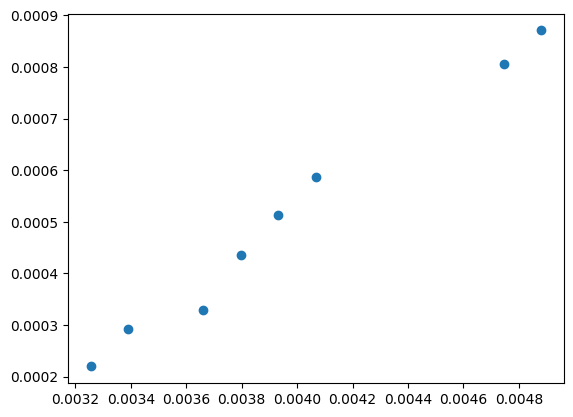

In [ ]:
plt.scatter(B,r)

Slope: 0.40039198410645255 ± 0.04501688802574037
Intercept: -0.0010815612890616253 ± 0.00018025752256318545
Residuals: [-0.01649384  0.17332463 -0.56081843 -0.03393496  0.19984851  0.38966698
 -0.12674068 -0.02485221]


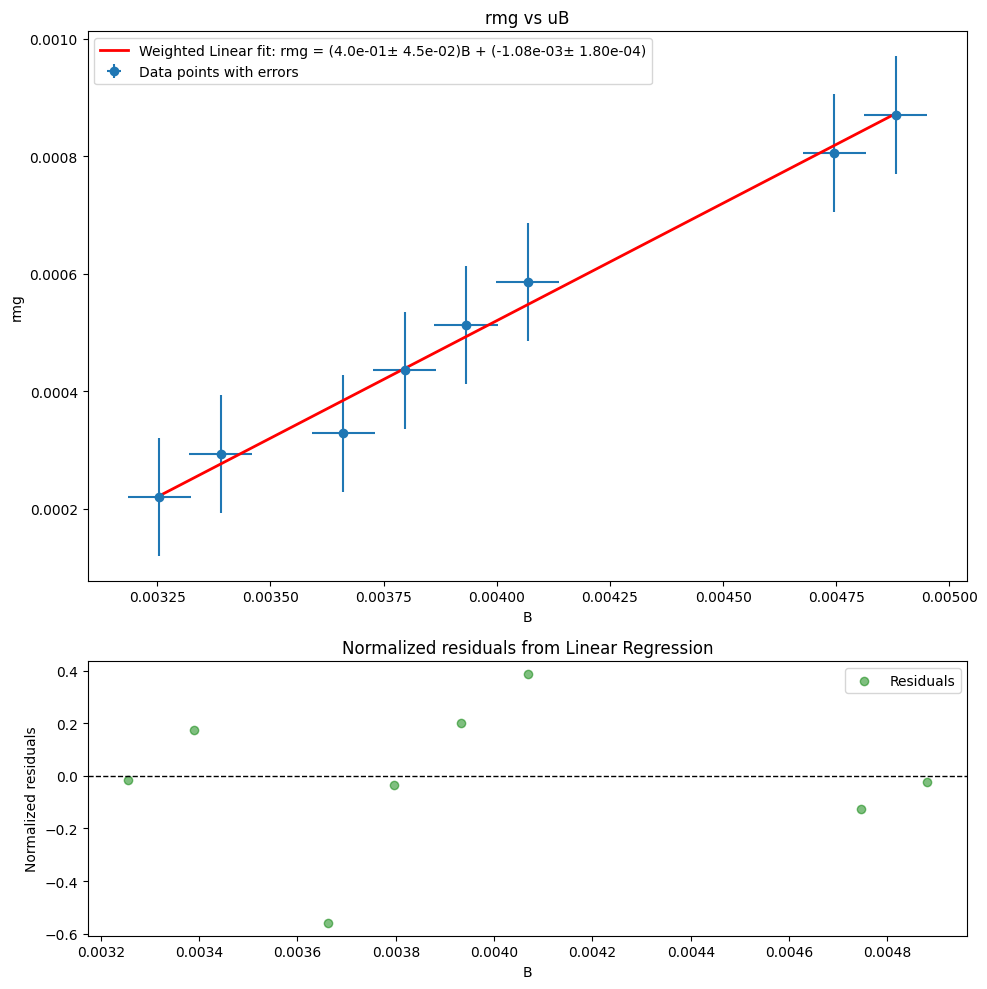

In [ ]:
# Define the linear function for curve fitting
def linear_function(X, a, b):
    return a * X + b

# Perform the curve fitting considering the uncertainties
popt, pcov = curve_fit(linear_function, B, r, sigma=dB, absolute_sigma=True)

# Get the slope and intercept
slope = popt[0]
intercept = popt[1]

# Get the standard errors for the parameters
slope_std_err = np.sqrt(pcov[0, 0])
intercept_std_err = np.sqrt(pcov[1, 1])

## Setting variables
x = B
y = r
yerr = dr
xerr = dB

# Predict the Y values
Y_pred = linear_function(x, *popt)

# Calculate normalized residuals
residuals = (y - Y_pred)/yerr

print(f"Slope: {slope} ± {slope_std_err}")
print(f"Intercept: {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})  # 2 rows, 1 column, width = 10 inches, height = 10 inches

# Plot the regression line
ax1.errorbar(x, y, yerr, xerr,  fmt='o', label='Data points with errors')
ax1.plot(x, Y_pred, color='red', linewidth=2, label=f'Weighted Linear fit: rmg = ({slope:.1e}± {slope_std_err:.1e})B + ({intercept:.2e}± {intercept_std_err:.2e})')

ax1.set_xlabel('B')
ax1.set_ylabel('rmg')
ax1.legend(loc='upper left')
ax1.set_title('rmg vs uB')

# Plot normalized residuals
ax2.scatter(x, residuals, color='green', alpha=0.5, label='Residuals')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('B')
ax2.set_ylabel('Normalized residuals')
ax2.legend(loc='upper right')
ax2.set_title('Normalized residuals from Linear Regression')

plt.tight_layout()

# Save the figure as a PDF file
plt.savefig('Weighted_linear_regression_with_normalized_residuals_curve_fit.pdf', format='pdf')
plt.show()



In [ ]:
I_osc = np.array([
    1.0,
    1.2,
    1.5,
    1.8,
    2.2,
    2.6,
    3.0,
    3.4,
    3.7,
    4.0
])

T = np.array([
    33.81,
    29.24,
    25.86,
    24.23,
    22.29,
    19.76,
    19.36,
    17.91,
    17.63,
    17.06
])

In [ ]:
B_osc = I_am * I_osc
B_osc1 = 1/B_osc
B_osc1

array([737.46312684, 614.5526057 , 491.64208456, 409.70173714,
       335.2105122 , 283.63966417, 245.82104228, 216.90091966,
       199.31435861, 184.36578171])

In [ ]:
T_osc = T/20
T_osc
t_prueba = T_osc**2
t_prueba

array([2.85779025, 2.137444  , 1.671849  , 1.46773225, 1.24211025,
       0.976144  , 0.937024  , 0.80192025, 0.77704225, 0.727609  ])

In [ ]:
dT = 0.01
dB1 = 0.00007


Slope: 0.0035242602361340177 ± 4.6179695959244234e-05
Intercept: 0.04574093086413064 ± 0.01563012292171315
Residuals: [ 6.30101584 -2.535576   -4.1209041  -0.90401245  0.67295829 -3.5028806
  1.28851987 -0.459853    1.63730293  1.88247806]


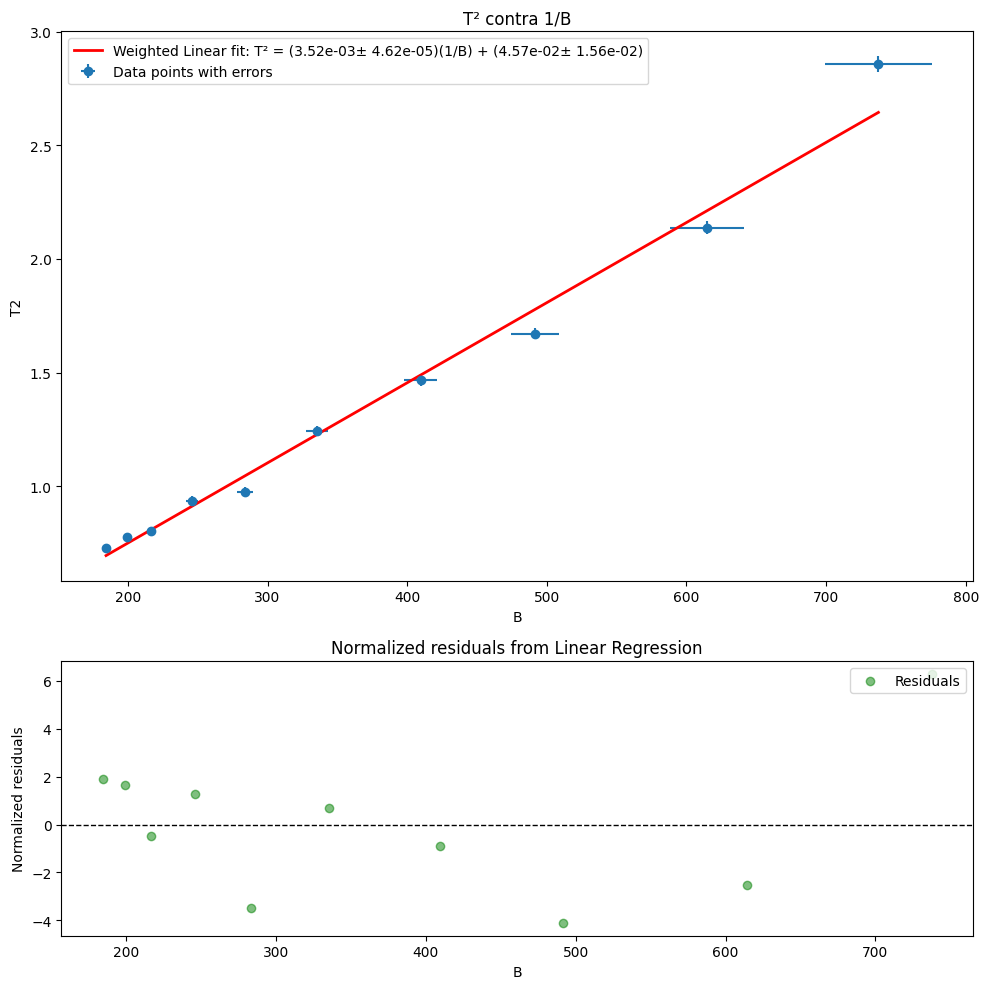

miu = 0.4123 ± 0.0054


In [ ]:
# Define the linear function for curve fitting
def linear_function(X, a, b):
    return a * X + b
x1 = B_osc1
y1 = T_osc**2
yerr1 = 2 * (dT) * T_osc
xerr1 = dB1 * B_osc1**2
# Perform the curve fitting considering the uncertainties
popt, pcov = curve_fit(linear_function, B_osc1, T_osc**2, sigma=yerr1, absolute_sigma=True)

# Get the slope and intercept
slope1 = popt[0]
intercept1 = popt[1]

# Get the standard errors for the parameters
slope_std_err1 = np.sqrt(pcov[0, 0])
intercept_std_err1 = np.sqrt(pcov[1, 1])

## Setting variables


# Predict the Y values
Y_pred1 = linear_function(x1, *popt)

# Calculate normalized residuals
residuals1 = (y1 - Y_pred1)/yerr1

print(f"Slope: {slope1} ± {slope_std_err1}")
print(f"Intercept: {intercept1} ± {intercept_std_err1}")
print(f"Residuals: {residuals1}")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})  # 2 rows, 1 column, width = 10 inches, height = 10 inches

# Plot the regression line
ax1.errorbar(x1, y1, yerr1, xerr1,  fmt='o', label='Data points with errors')
ax1.plot(x1, Y_pred1, color='red', linewidth=2,
         label=f'Weighted Linear fit: T² = ({slope1:.2e}± {slope_std_err1:.2e})(1/B) + ({intercept1:.2e}± {intercept_std_err1:.2e})')

ax1.set_xlabel('B')
ax1.set_ylabel('T2')
ax1.legend(loc='upper left')
ax1.set_title('T² contra 1/B')

# Plot normalized residuals
ax2.scatter(x1, residuals1, color='green', alpha=0.5, label='Residuals')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('B')
ax2.set_ylabel('Normalized residuals')
ax2.legend(loc='upper right')
ax2.set_title('Normalized residuals from Linear Regression')

plt.tight_layout()

# Save the figure as a PDF file
plt.savefig('Weighted_linear_regression_with_normalized_residuals_curve_fit.pdf', format='pdf')
plt.show()
b = slope1
db = slope_std_err1

m = 0.1415
r = 0.0255

miu_NUM = 4*(np.pi**2)*2*m*r**2
miu_dem = 5*b
miu = miu_NUM/miu_dem

sigma_miu = miu * (db/b)

print(f"miu = {miu:.4f} ± {sigma_miu:.4f}")

In [ ]:
b = slope1

In [ ]:
m = 0.1415

In [ ]:
miu_NUM = 4*(np.pi**2)*2*m*0.027**2
miu_dem = 5*b
miu = miu_NUM/miu_dem
miu

np.float64(0.4468679575261846)

In [ ]:
b = slope1
db = slope_std_err1   # <- la incertidumbre que sale del ajuste

m = 0.1415
r = 0.0255

miu_NUM = 4*(np.pi**2)*2*m*r**2
miu_dem = 5*b
miu = miu_NUM/miu_dem

# Si m y r son valores exactos (sin incertidumbre propia):
sigma_miu = miu * (db/b)

print(f"miu = {miu:.4f} ± {sigma_miu:.4f}")

miu = 0.4123 ± 0.0054


In [ ]:
print(b, db)
print(miu, sigma_miu)

0.0035242602361340177 4.6179695959244234e-05
0.41227647957894975 0.0054022124367831366


In [ ]:
h = 1e-5
def derivada_numerica(f,x):
 return (f(x+h) - f(x - h)) /2 * h

def reflection_coefficient(theta_i,theta_t):
    return (np.tan(theta_i - theta_t))**2/ (np.tan(theta_i + theta_t))**2


In [ ]:
reflection_coefficient(45,34.5)

np.float64(1.6760350707649203)

# Exp 3

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import requests
import io

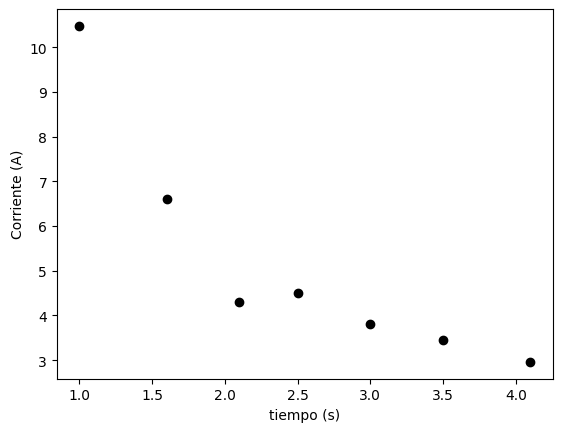

In [ ]:
x= np.array([1.0, 1.6, 2.1, 2.5, 3, 3.5, 4.1])
y= np.array([10.48, 6.6, 4.29, 4.5, 3.8, 3.45, 2.96])
errorxy = np.full_like(x, 0.01, dtype=float)

plt.scatter(x, y, c="k")
plt.xlabel('tiempo (s)')
plt.ylabel('Corriente (A)')
plt.show()

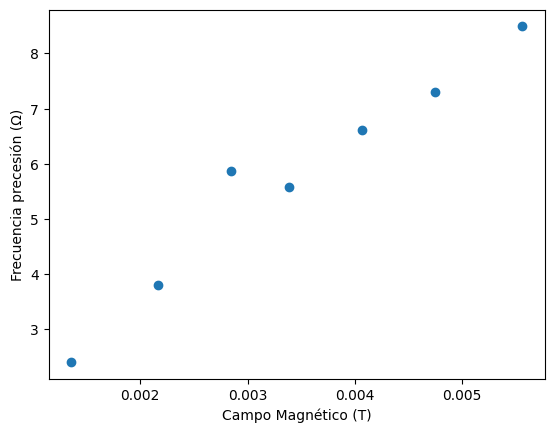

In [ ]:
x1= np.array([0.001356, 0.002169, 0.002847, 0.003390, 0.004068, 0.004746, 0.005559])
y1= np.array([2.40, 3.81, 5.87, 5.58, 6.61, 7.30, 8.49])
errorx1= np.array([0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01])
errory1= np.full_like(y, 0.07E-3, dtype=float)

plot1= plt.scatter (x1, y1)
plt.ylabel('Frecuencia precesión (Ω)')
plt.xlabel('Campo Magnético (T)')
plot1

Slope: 1231.1550264855016 ± 3.71855286703881
Intercept: 1.626079917045744 ± 0.015142980039981541
Residuals: [-44.77630665 -24.32275847  73.88217226 -21.96954568  -2.44185648
 -16.91416727   1.99292907]


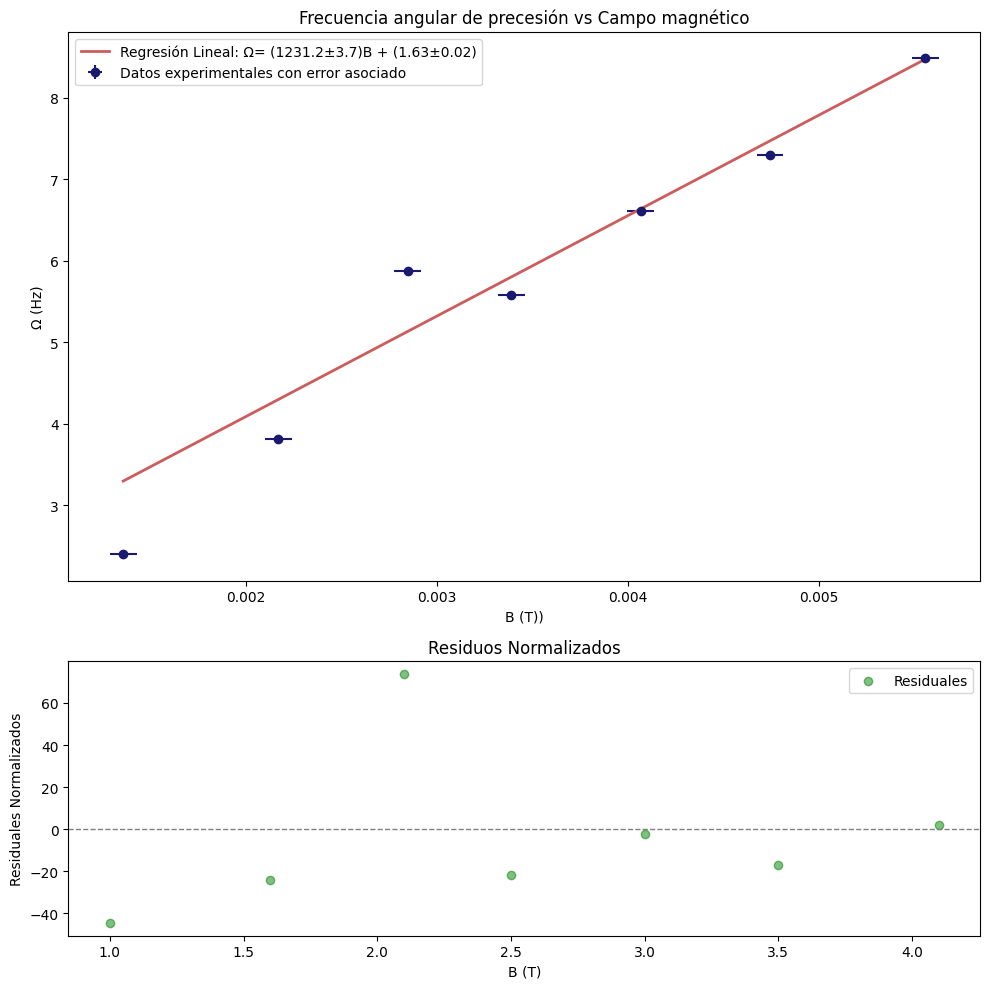

In [ ]:
# Define the linear function for curve fitting
def linear_function(X, a, b):
    return a * X + b

# Adjust errorxy to match the length of x and y
# Assuming the intention was a constant error of 0.01 for each data point

# Perform the curve fitting considering the uncertainties
popt, pcov = curve_fit(linear_function, x1, y1, sigma=errorx1, absolute_sigma=True)

# Get the slope and intercept
slope = popt[0]
intercept = popt[1]

# Get the standard errors for the parameters
slope_std_err = np.sqrt(pcov[0, 0])
intercept_std_err = np.sqrt(pcov[1, 1])

## Setting variables

yerr = errorx1
xerr = errory1

# Predict the Y values
Y_pred = linear_function(x1, *popt)

# Calculate normalized residuals
residuals = (y1 - Y_pred)/yerr

print(f"Slope: {slope} ± {slope_std_err}")
print(f"Intercept: {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})  # 2 rows, 1 column, width = 10 inches, height = 10 inches

# Plot the regression line
ax1.errorbar(x1, y1, yerr, xerr,  fmt='o', c="midnightblue", label='Datos experimentales con error asociado')
ax1.plot(x1, Y_pred, color='indianred', linewidth=2, label= f'Regresión Lineal: Ω= ({slope:.1f}±{slope_std_err:.1f})B + ({intercept:.2f}±{intercept_std_err:.2f})')
ax1.set_xlabel('B (T))')
ax1.set_ylabel('Ω (Hz)')
ax1.legend(loc='upper left')
ax1.set_title('Frecuencia angular de precesión vs Campo magnético')

# Plot normalized residuals
ax2.scatter(x, residuals, color='green', alpha=0.5, label='Residuales')
ax2.axhline(0, color='grey', linewidth=1, linestyle='--')
ax2.set_title("Residuos Normalizados")
ax2.set_xlabel('B (T)')
ax2.set_ylabel('Residuales Normalizados')
ax2.legend(loc='upper right')

plt.tight_layout()


In [ ]:
slope: 1231.1550264855016
const= 2*np.pi*5*2/5*0.027**2*0.0425
miu= slope*const
miu_incer= 0.06
print("μ=" ,f'({miu:.2f} ± {miu_incer})')


μ= (0.48 ± 0.06)
